<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/SFDS/egg_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Royal Draconic Conservatory**

<div style="text-align: center;">
   <img src="https://raw.githubusercontent.com/kwanda2426/projects/main/SFDS/egg.png"  width="800">
</div>




# **Importing Libraries**

In [86]:
!pip -q install plotly scikit-learn tabulate pandas xgboost

In [87]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px
from scipy.stats import kurtosis


#Feature engineering, selection and Model training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate
from IPython.display import display


# **Data acquisition**

#### Main Data

In [88]:
# Loading Data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/SFDS/egg_data.csv"
df = pd.read_csv(url)
df.head()

,SPEC,VOL,MASS,AGE,SPOT,NEST,TEMP,SPC
0,Wyvern,398,665,446,10,Coastal,38.7,Wyvern
1,Hydra,13,7,477,8,Volcanic,82.9,Hydra
2,Hydra,61,32,74,8,Coastal,29.0,Hydra
3,Hydra,44,68,207,9,Forest,21.8,Hydra
4,Dragon,99,120,61,2,Volcanic,70.9,Dragon


In [89]:
# Create the data as a list of dictionaries
variables = [

    {"variable": "MASS", "description": "Mass of the egg (kg)."},
    {"variable": "VOL", "description": "Volume of the egg (litres)."},
    {"variable": "AGE", "description": "Age of the egg (days since laying)."},
    {"variable": "NEXT", "description": "Type of nest (categorical; Volcanic, Forest, Mountain, Coastal or Swamp)."},
    {"variable": "SPOT", "description": "Number of visible shell spots"},
    {"variable": "TEMP", "description": " Surface Temprature of the egg in centigrade."},
    {"variable": "SPEC", "description": " Target variable (Dragon, Wyvern, Hydra)."},


]


# Display the DataFrame
var_desc = pd.DataFrame(variables)
var_desc_final = var_desc.reset_index(drop = True)

# Display the DataFrame
print(tabulate(var_desc_final, headers = 'keys', tablefmt = 'grid'))

+----+------------+---------------------------------------------------------------------------+
|    | variable   | description                                                               |
+====+============+===========================================================================+
|  0 | MASS       | Mass of the egg (kg).                                                     |
+----+------------+---------------------------------------------------------------------------+
|  1 | VOL        | Volume of the egg (litres).                                               |
+----+------------+---------------------------------------------------------------------------+
|  2 | AGE        | Age of the egg (days since laying).                                       |
+----+------------+---------------------------------------------------------------------------+
|  3 | NEXT       | Type of nest (categorical; Volcanic, Forest, Mountain, Coastal or Swamp). |
+----+------------+---------------------

# **Data Exploratory Analysis**

Data preprocessing is vital because it transforms messy raw data into a clean, consistent, and structured format, which is essential for accurate analysis and effective machine learning models.
Issues like missing values, inconsistencies, errors, and outliers are addressed to improve data quality,leads to more reliable and meaningful insights for decision-making and ultimately enhances the performance and accuracy of models.



In [90]:
df_main = df.copy()

#### Reviewing and Renaming Columns


In [91]:
# data columns
df_main.columns

Index(['SPEC', 'VOL', 'MASS', 'AGE', 'SPOT', 'NEST', 'TEMP', 'SPC'], dtype='object')

- There are column names that have UPPERCASE. All variable names are converted to lowercase.

In [92]:
# Changing column names
df_main.columns = df_main.columns.str.replace(' ', '_', regex=False).str.lower()
df_main.head()

,spec,vol,mass,age,spot,nest,temp,spc
0,Wyvern,398,665,446,10,Coastal,38.7,Wyvern
1,Hydra,13,7,477,8,Volcanic,82.9,Hydra
2,Hydra,61,32,74,8,Coastal,29.0,Hydra
3,Hydra,44,68,207,9,Forest,21.8,Hydra
4,Dragon,99,120,61,2,Volcanic,70.9,Dragon


#### Dataset Dimensions and Variable Type

In [93]:
df = df_main.copy()

In [94]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following variables with missing values:')
print('')
major_missing = []
for i in df_main.columns:
  missing_values = 100*df_main[i].isnull().sum()/df_main.shape[0]
  print(i+', with {}% of missing data'.format(missing_values))


Data has 500 rows and 8 Columns

Data has the following variables with missing values:

spec, with 0.0% of missing data
vol, with 0.0% of missing data
mass, with 0.0% of missing data
age, with 0.0% of missing data
spot, with 0.0% of missing data
nest, with 0.0% of missing data
temp, with 0.0% of missing data
spc, with 0.0% of missing data


- No missing data.

#### SPEC - Target Variable Distribution

<Axes: >

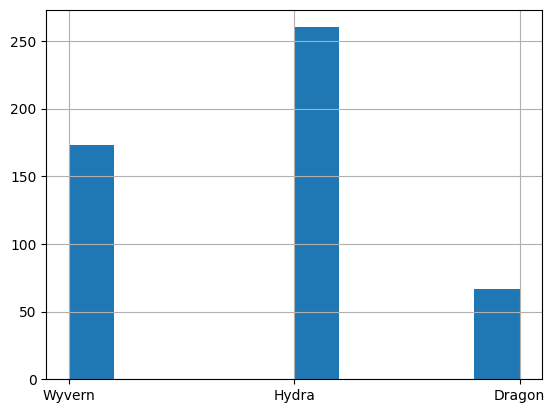

In [95]:
df_main.spec.hist()

In [96]:
# Number of observations
df_main.spec.value_counts()

,count
spec,
Hydra,260
Wyvern,173
Dragon,67


**Observations**
- Hydra is the dominant class
Over half of the dataset belongs to Hydra.
This suggests the dataset is biased toward Hydra observations.
- Dragon is underrepresented compared to Wyvern and Hydra.

This could create a class imbalance problem in modelling implying that the model may learn Hydra and Wyvern  patterns better than Dragon patterns.
Metrics like accuracy alone may become misleading. Hence stratification is needed when splitting train/test data.

 #### NEST-  Type of nest Distribution

<Axes: >

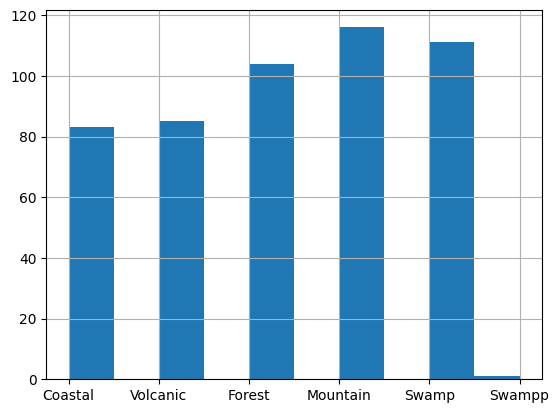

In [97]:
df_main.nest.hist()

In [98]:
# Number of observations
df_main.nest.value_counts()

,count
nest,
Mountain,116
Swamp,111
Forest,104
Volcanic,85
Coastal,83
Swampp,1


**Observations**
- There's an issue with Swampp - it is a data issue which was supposed to be Swampp. This can be dropped because it is one datapoint.
- The counts across Mountain, Swamp, Forest, Volcanic, and Coastal nests are relatively close, meaning no single category heavily dominates the dataset.
- Mountain nests are the most common while Coastal nests are the least common
Mountain has the highest number of observations (116), whereas Coastal has the lowest (83), noting that the difference is not extreme.
- The feature is suitable for machine learning models
Because the categories are reasonably balanced, the feature can provide useful predictive information without causing major class imbalance issues.

#### Summary Statistics

In [99]:
#describing numerical columns
df_main.describe().T

,count,mean,std,min,25%,50%,75%,max
vol,500.0,92.1920,153.385623,0.0,11.00,37.5,99.25,1299.0
mass,500.0,173.7380,512.251904,-132.0,7.00,31.0,110.25,5162.0
age,500.0,250.5240,144.517639,0.0,133.00,247.5,380.00,500.0
spot,500.0,6.4640,5.260423,0.0,2.00,5.0,9.00,20.0
temp,500.0,40.7854,20.144801,6.3,27.75,35.4,44.50,95.9


**Observations**:

- Both vol and mass appear heavily right-skewed. The means are far above the medians, which usually indicates potential outliers. This means that the data might need to be transformed or create a new feature from the two.

- mass has a negative minimum value. This is strange because a physical mass should not be negative. This might be because of calibration errors or data corruption. These data points can be removed or treated as anomalies.

- age looks uniformly distributed.

- spot behave like categorical features. it can be beneficial to bin these values.

- temp behave normal compared to the other features.

In [100]:
# negative mass
df_main[df_main['mass'] < 0].shape

(1, 8)

The negative mass issue looks like a single data point. This can be removed.

#### Feature Distribution

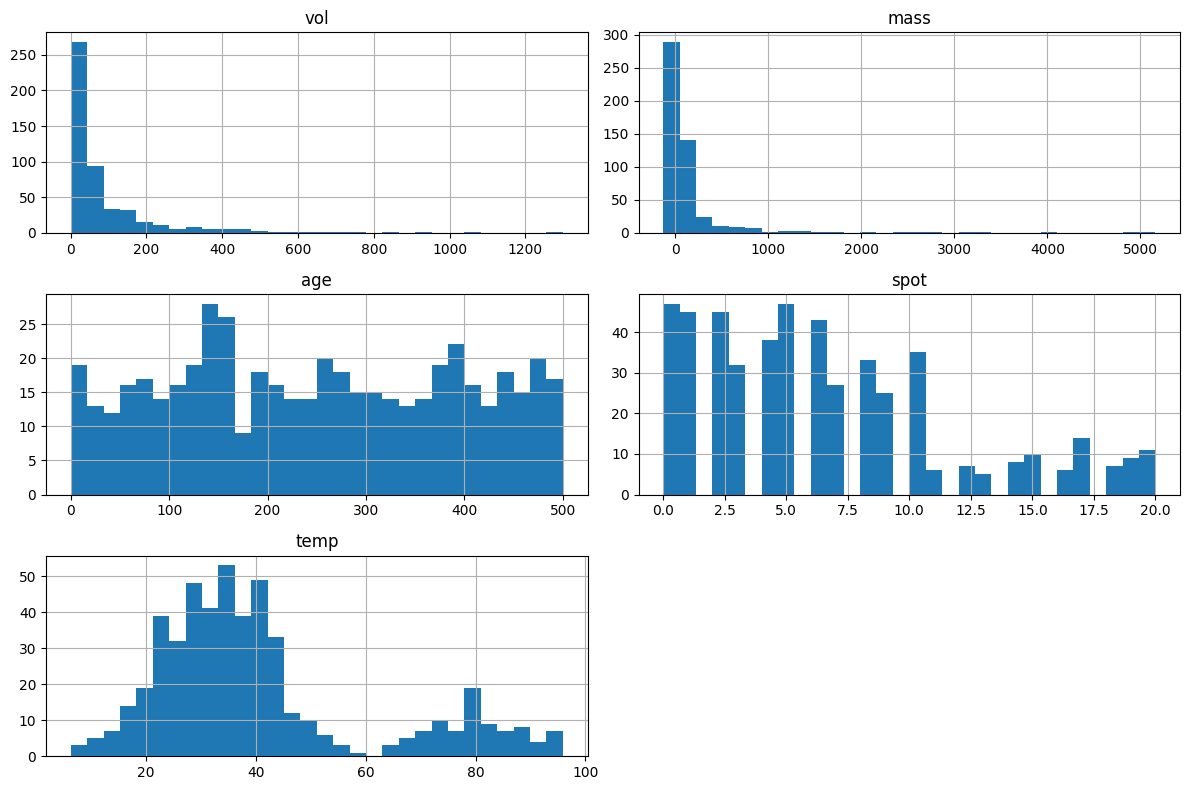

In [101]:
# Building histograms
df = df_main.copy()
df.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

- This confirms what is shown by the summary statistics.

# **Feature Selection and Engineering**

This is a vital step - Feature transformation improves model performance by making data easier to learn from, especially when features have different scales or distributions. Scaling prevents features with larger numerical values from disproportionately influencing the model's learning. When features have vastly different ranges (e.g., one feature ranges from 0-10 and another from 0-10,000), the model can become biased toward the feature with the larger magnitude, simply because its values are larger. Binning and other transformations help reduce skewness, limit the impact of outliers, and capture non-linear relationships.

In [109]:
# creating copy of dataset
df_semi = df_main.copy()

# data points excluding negative mass
df_semi = df_semi[df_semi['mass'] > 0]

# Remove data point of Swampp
df_semi = df_semi[df_semi['nest'] !=  'Swampp']

In [110]:
# create density feature from mass and volume - This feature is transformed
df_semi['density'] = np.log1p(df_semi['mass'].clip(lower = 0)) / np.log1p(df_semi['vol'] + 1)

- This deals with the skewness of these two features.

In [111]:
# initialise encoder
le = LabelEncoder()

# Encoding Nest feature
df_semi['nest_encoded'] = le.fit_transform(df_semi['nest'])

# Encoding target variable
df_semi['spec_encoded'] = le.fit_transform(df_semi['spec'])

- LabelEncoder() provides a simple, consistent, and lossless way to convert variables to numeric because most machine learning algorithms can only work with numbers, not text or categories.

In [112]:
# initialise scaler
scaler = StandardScaler()

# scale age using standard scaler
df_semi['age_scaled'] = scaler.fit_transform(df_semi[['age']])

# scale age using standard scaler
df_semi['temp_scaled'] = scaler.fit_transform(df_semi[['temp']])

- StandardScaler standardize numeric features so they have mean 0 and variance 1, ensuring all features contribute equally and improving model performance.

In [113]:
# binning spot feature
df_semi['spot_bin'] = np.where(
    df_semi['spot'] <= 5, 0,
    np.where(df_semi['spot'] <= 10, 1, 3)
)

- Binning is useful because it simplifies continuous data into categories, reducing noise, and helping models handle non-linear relationships.

In [114]:
df_semi.head()

,spec,vol,mass,age,spot,nest,temp,spc,density,nest_encoded,spec_encoded,age_scaled,temp_scaled,spot_bin
0,Wyvern,398,665,446,10,Coastal,38.7,Wyvern,1.085092,0,2,1.348756,-0.098936,1
1,Hydra,13,7,477,8,Volcanic,82.9,Hydra,0.767874,4,1,1.564454,2.102293,1
2,Hydra,61,32,74,8,Coastal,29.0,Hydra,0.843928,0,1,-1.239619,-0.582011,1
3,Hydra,44,68,207,9,Forest,21.8,Hydra,1.105903,1,1,-0.314205,-0.940582,1
4,Dragon,99,120,61,2,Volcanic,70.9,Dragon,1.039147,4,0,-1.330073,1.504674,0


In [115]:
df_semi.columns

Index(['spec', 'vol', 'mass', 'age', 'spot', 'nest', 'temp', 'spc', 'density',
       'nest_encoded', 'spec_encoded', 'age_scaled', 'temp_scaled',
       'spot_bin'],
      dtype='object')

In [116]:
#  final dataframe
df_final = df_semi[['density','nest_encoded','age_scaled','temp_scaled','spot_bin','spec_encoded']]

# Rename specific columns
df_final = df_final.rename(columns={
    'nest_encoded': 'nest',
    'age_scaled': 'age',
    'temp_scaled': 'temp',
    'spot_bin': 'spot',
    'spec_encoded': 'spec'
})

In [117]:
df_final.head()

,density,nest,age,temp,spot,spec
0,1.085092,0,1.348756,-0.098936,1,2
1,0.767874,4,1.564454,2.102293,1,1
2,0.843928,0,-1.239619,-0.582011,1,1
3,1.105903,1,-0.314205,-0.940582,1,1
4,1.039147,4,-1.330073,1.504674,0,0


In [118]:
df_final.spec.value_counts()

,count
spec,
1,243
2,166
0,61


In [119]:
df_main.spec.value_counts()

,count
spec,
Hydra,260
Wyvern,173
Dragon,67


#### Data Split
Splitting data into training and testing sets is essential to evaluate a model's performance on new, unseen data and prevent overfitting. The training set teaches the model patterns, while the untouched test set provides an unbiased assessment of its generalisation ability, ensuring the model performs accurately in real-world scenarios rather than just on the data it learned from.


In [120]:
# data split

# features and target variable
X = df_final.drop(['spec'], axis = 1)
y = df_final['spec']

In [121]:
 # Train- test Split: 80% train and 20% test -- random state = 42, ensure the reproducibility of the data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# **Model Construction**

In this step, data is training data fed to the model. Training a model is essential because it allows the algorithm to learn patterns and relationships from data so it can make accurate predictions or decisions on new, unseen inputs. Without training, the model would have no understanding of how features relate to outcomes.

XGBoost contributes:
handles nonlinearity well
strong on tabular + missing patterns
captures feature interactions explicitly
 Neural Network contributes:
learns dense latent representations
captures smooth nonlinear boundaries
generalizes differently from trees
Stacking layer contributes:
learns optimal combination of both models
reduces overfitting from single model bias
improves calibration of probabilities

# **Model Evaluation**

Models are evaluated using the validation dataset. Validating these trained models is crucial because it helps identify which one performs best to unseen data—without touching the test set. This step acts like a rehearsal before the final performance: it reveals whether the model is overfitting (memorising the training data) or underfitting (failing to learn enough). By evaluating on the validation set, we can select the most promising model and fine-tune its hyperparameters, ensuring that when it is finally tested, the true predictive power is measured — not just luck or overtraining.

# **Interpretation**



In [108]:
# Evaluation Results
#print(tabulate(results_df, headers='keys', tablefmt='grid'))